# Logistic regression

# #Phase 2: Predictive Modeling & Performance Evaluation

This notebook implements supervised learning algorithms (Random Forest and Logistic Regression) to classify forest cover types. It includes hyperparameter optimization using RandomizedSearchCV and detailed diagnostic analysis via confusion matrices.

Loaded: /Users/maojianwen/forest_cover_clean.csv
Shape: (30833, 55) | Total missing: 0
Target classes: ['Aspen', 'Cottonwood/Willow', 'Douglas-fir', 'Krummholz', 'Lodgepole Pine', 'Ponderosa Pine', 'Spruce/Fir']

Dtypes summary:
 int64     54
object     1
Name: count, dtype: int64

Counts -> numeric_cont=10, soil_onehot=40, wilderness_flags=4


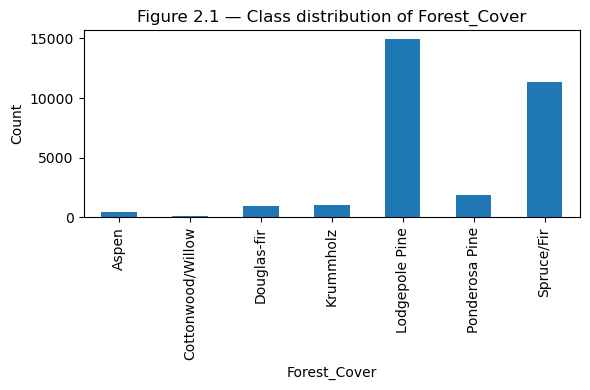

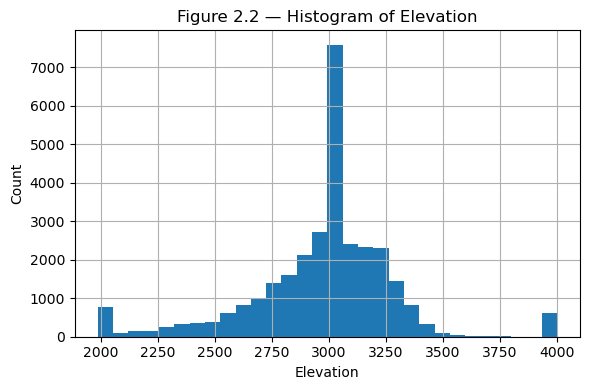

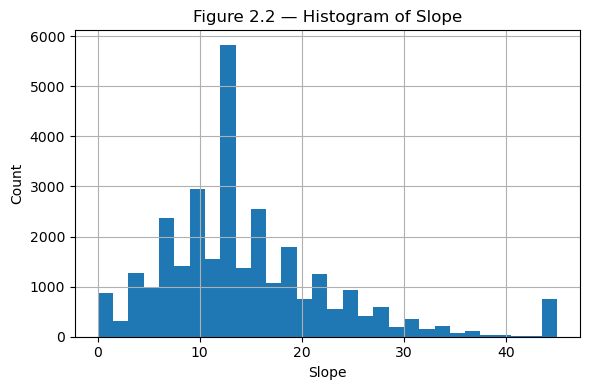

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Load the cleaned data
CLEAN_PATHS = [
    Path("forest_cover_clean.csv"),
    Path("desktop/comp5310/forest_cover_clean.csv"),
]
for p in CLEAN_PATHS:
    if p.exists():
        df = pd.read_csv(p)
        print("Loaded:", p.resolve())
        break
else:
    raise FileNotFoundError("找不到 forest_cover_clean.csv，请确认路径。")

TARGET = "Forest_Cover"
assert TARGET in df.columns, f"Target '{TARGET}' 不在列名中：{df.columns[:10]}..."

# 2) Basic Information
n_rows, n_cols = df.shape
missing_total = int(df.isna().sum().sum())
print(f"Shape: {df.shape} | Total missing: {missing_total}")
print("Target classes:", sorted(df[TARGET].unique()))
print("\nDtypes summary:\n", df.dtypes.value_counts())

# Grouping columns
wilderness_names = ["Neota", "Rawah", "Comanche Peak", "Cache la Poudre"]
wilderness_cols = [c for c in df.columns if c in wilderness_names or c.startswith("Wilderness_Area")]
soil_cols = [c for c in df.columns if c.startswith("Soil_Type")]
one_hot_cols = set(wilderness_cols + soil_cols)
num_cont = [c for c in df.select_dtypes(include=["number"]).columns if c not in one_hot_cols and c != TARGET]

print(f"\nCounts -> numeric_cont={len(num_cont)}, soil_onehot={len(soil_cols)}, wilderness_flags={len(wilderness_cols)}")

# 3) Output Directory
FIG_DIR = Path("outputs/figs"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# Figure 2.1: Forest_Cover Category distribution
plt.figure(figsize=(6,4))
(df[TARGET].value_counts().sort_index()).plot(kind="bar")
plt.title("Figure 2.1 — Class distribution of Forest_Cover")
plt.xlabel("Forest_Cover"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_2_1_class_distribution.png", dpi=150)
plt.show()

# Figure 2.2 Elevation & Slope
for c in [col for col in ["Elevation","Slope"] if col in df.columns]:
    plt.figure(figsize=(6,4))
    df[c].hist(bins=30)
    plt.title(f"Figure 2.2 — Histogram of {c}")
    plt.xlabel(c); plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig_2_2_hist_{c.lower()}.png", dpi=150)
    plt.show()

In [ ]:
# === 3.2.1 Load clean data & split features/target ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
 
CLEAN_PATHS = [
    Path("forest_cover_clean.csv"),
    Path("desktop/comp5310/ass1/forest_cover_clean.csv")
]
for p in CLEAN_PATHS:
    if p.exists():
        df = pd.read_csv(p)
        print("Loaded:", p.resolve())
        break
else:
    raise FileNotFoundError("找不到 forest_cover_clean.csv，请确认路径。")

TARGET = "Forest_Cover"
assert TARGET in df.columns, f"Target '{TARGET}' 不在列名中：{df.columns[:10]}"

# One-hot features
w_names = ["Neota", "Rawah", "Comanche Peak", "Cache la Poudre"]
w_cols  = [c for c in df.columns if c in w_names or c.startswith("Wilderness_Area")]
soil_cols = [c for c in df.columns if c.startswith("Soil_Type")]
one_hot_cols = set(w_cols + soil_cols)

num_cols = [c for c in df.select_dtypes(include=["number"]).columns
            if c not in one_hot_cols and c != TARGET]
feature_cols = [c for c in df.columns if c != TARGET]

X = df[feature_cols].copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df[TARGET])
print("Encoded labels:", dict(zip(le.classes_, range(len(le.classes_)))))

# Layered segmentation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train/Test:", X_train.shape, X_test.shape)
print("Classes:", np.unique(y))

Loaded: /Users/maojianwen/forest_cover_clean.csv
Encoded labels: {'Aspen': 0, 'Cottonwood/Willow': 1, 'Douglas-fir': 2, 'Krummholz': 3, 'Lodgepole Pine': 4, 'Ponderosa Pine': 5, 'Spruce/Fir': 6}
Train/Test: (24666, 54) (6167, 54)
Classes: [0 1 2 3 4 5 6]


In [ ]:
# === 3.2.2 Scale numeric columns only ===
scaler = StandardScaler(with_mean=True, with_std=True)

X_train_s = X_train.copy()
X_test_s  = X_test.copy()

if len(num_cols) > 0:
    X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_s[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Scaled {len(num_cols)} numeric columns; left {len(one_hot_cols)} one-hot columns unchanged.")

Scaled 10 numeric columns; left 44 one-hot columns unchanged.


In [ ]:
# === 3.2.3 Baseline multinomial LR ===
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
base_lr = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1
)
base_lr.fit(X_train_s, y_train)
y_pred_base = base_lr.predict(X_test_s)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("Baseline Macro-F1:", f1_score(y_test, y_pred_base, average="macro"))

Baseline Accuracy: 0.4718663856007783
Baseline Macro-F1: 0.3729081211313143


In [ ]:
# === 3.2.4 Grid search on C (L2 strength) ===
param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
lr = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train_s, y_train)

best_lr = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

y_pred = best_lr.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
macro = f1_score(y_test, y_pred, average="macro")
micro = f1_score(y_test, y_pred, average="micro")
print(f"Test Accuracy={acc:.4f} | Macro-F1={macro:.4f} | Micro-F1={micro:.4f}")

print("\nClassification report (per class):")
print(classification_report(y_test, y_pred, digits=3))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

Best params: {'C': 10.0}
Best CV macro-F1: 0.38648020135737343
Test Accuracy=0.4724 | Macro-F1=0.3737 | Micro-F1=0.4724

Classification report (per class):
              precision    recall  f1-score   support

           0      0.064     0.673     0.117        98
           1      0.195     0.929     0.323        28
           2      0.248     0.537     0.339       188
           3      0.191     0.750     0.305       212
           4      0.742     0.427     0.542      2986
           5      0.553     0.344     0.424       378
           6      0.638     0.508     0.566      2277

    accuracy                          0.472      6167
   macro avg      0.376     0.595     0.374      6167
weighted avg      0.645     0.472     0.521      6167



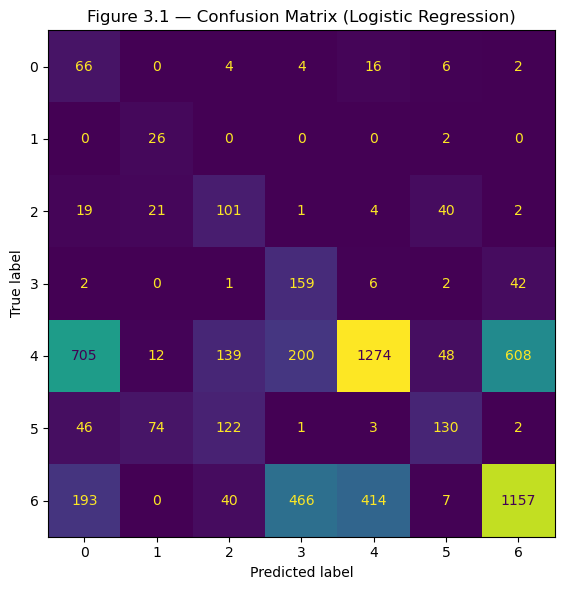

In [ ]:
# === 3.2.5 Confusion matrix ===
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = np.unique(y) 
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(ax=ax, colorbar=False)
plt.title("Figure 3.1 — Confusion Matrix (Logistic Regression)")
plt.tight_layout()
plt.show()

Cache la Poudre    33.510452
Rawah              25.234298
Soil_Type39        20.292860
Soil_Type2         19.862480
Soil_Type3         19.848913
Soil_Type11        16.946464
Soil_Type14        16.006814
Neota              15.809467
Soil_Type38        15.119253
Soil_Type16        14.992660
Comanche Peak      14.102548
Soil_Type4         13.979402
Soil_Type20        13.358173
Soil_Type10        12.221527
Soil_Type13        12.063659
dtype: float64

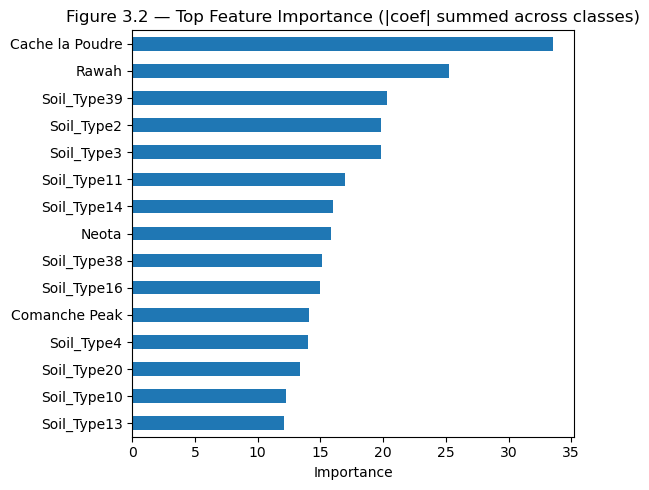

In [ ]:
# === 3.2.6 Feature importance from coefficients ===
coef = best_lr.coef_                        # shape: (n_classes, n_features)
feat_imp = pd.Series(np.abs(coef).sum(axis=0), index=feature_cols).sort_values(ascending=False)

topN = 15
display(feat_imp.head(topN))

plt.figure(figsize=(6,5))
feat_imp.head(topN)[::-1].plot(kind="barh")
plt.title("Figure 3.2 — Top Feature Importance (|coef| summed across classes)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Decision Tree

In [ ]:
# Decision tree baseline model (default hyperparameters)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

df = pd.read_csv("forest_cover_clean.csv")
le = LabelEncoder()
df["Forest_Cover"] = le.fit_transform(df["Forest_Cover"])

# Divide the data (stratified sampling, 80/20)
X = df.drop(columns=["Forest_Cover"])
y = df["Forest_Cover"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train the baseline model (default parameters)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Training set accuracy
train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"[Baseline DT] Train Accuracy: {train_acc:.4f}")

# Test set evaluation (Accuracy and Macro-F1)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"[Baseline DT] Test Accuracy: {acc:.4f}")
print(f"[Baseline DT] Macro-F1:     {macro_f1:.4f}")

# Show the top 10 important features
importances = pd.Series(clf.feature_importances_, index=X.columns)
print("\nTop-10 Feature Importances:")
print(importances.sort_values(ascending=False).head(10).to_string())

[Baseline DT] Train Accuracy: 1.0000
[Baseline DT] Test Accuracy: 0.6630
[Baseline DT] Macro-F1:     0.5529

Top-10 Feature Importances:
Elevation                             0.221271
Horizontal_Distance_To_Roadways       0.104759
Horizontal_Distance_To_Fire_Points    0.083123
Horizontal_Distance_To_Hydrology      0.070329
Cache la Poudre                       0.067868
Vertical_Distance_To_Hydrology        0.062731
Hillshade_Noon                        0.061024
Aspect                                0.060619
Hillshade_3pm                         0.053239
Slope                                 0.051161


Best Params: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 20}
Best CV Mean Accuracy: 0.6837


<Figure size 800x600 with 0 Axes>

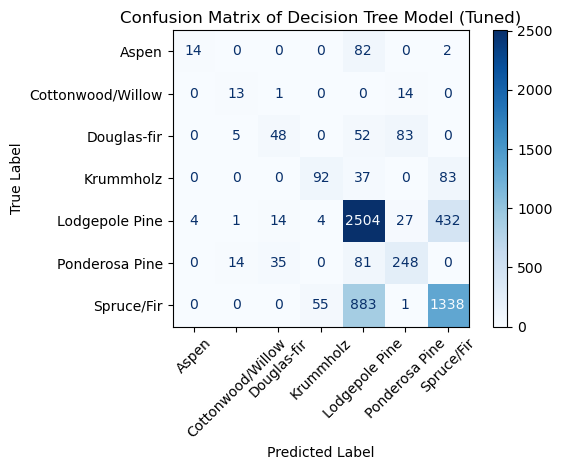

Train Accuracy: 0.7300
Test  Accuracy: 0.6903
Macro-Precision: 0.6207
Macro-Recall:    0.4827
Macro-F1:        0.5106

Classification Report:
                    precision    recall  f1-score   support

            Aspen     0.7778    0.1429    0.2414        98
Cottonwood/Willow     0.3939    0.4643    0.4262        28
      Douglas-fir     0.4898    0.2553    0.3357       188
        Krummholz     0.6093    0.4340    0.5069       212
   Lodgepole Pine     0.6881    0.8386    0.7559      2986
   Ponderosa Pine     0.6649    0.6561    0.6605       378
       Spruce/Fir     0.7213    0.5876    0.6476      2277

         accuracy                         0.6903      6167
        macro avg     0.6207    0.4827    0.5106      6167
     weighted avg     0.6903    0.6903    0.6790      6167


Top-10 Feature Importances:
Elevation                             0.428470
Cache la Poudre                       0.171461
Horizontal_Distance_To_Roadways       0.052509
Horizontal_Distance_To_Fire_Points 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

df = pd.read_csv("forest_cover_clean.csv")
le = LabelEncoder()
df["Forest_Cover"] = le.fit_transform(df["Forest_Cover"])

X = df.drop(columns=["Forest_Cover"])
y = df["Forest_Cover"]

# Divide the data (stratified sampling, 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Set parameter search scope
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": [None, "sqrt", "log2"]
}

# Grid search using 5-fold cross validation
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

# Output optimal parameters and verification scores
print("Best Params:", grid.best_params_)
print(f"Best CV Mean Accuracy: {grid.best_score_:.4f}")

# Use the optimal model to predict the test set
best = grid.best_estimator_
y_pred = best.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Draw a visualization
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', colorbar=True)
plt.title("Confusion Matrix of Decision Tree Model (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate performance indicators
train_acc = accuracy_score(y_train, best.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)
macro_f1  = f1_score(y_test, y_pred, average="macro")
macro_p   = precision_score(y_test, y_pred, average="macro")
macro_r   = recall_score(y_test, y_pred, average="macro")

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")
print(f"Macro-Precision: {macro_p:.4f}")
print(f"Macro-Recall:    {macro_r:.4f}")
print(f"Macro-F1:        {macro_f1:.4f}")

# Classification Report
report_txt = classification_report(
    y_test, y_pred, target_names=le.classes_, digits=4
)
print("\nClassification Report:\n", report_txt)
importances = pd.Series(best.feature_importances_, index=X.columns)
print("\nTop-10 Feature Importances:")
print(importances.sort_values(ascending=False).head(10).to_string())


# Random Forest

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=221; total time=   4.4s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=9, n_estimators=393; total time=   6.6s


Exception ignored in: <function ResourceTracker.__del__ at 0x1040a5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=221; total time=   4.6s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=6, n_estimators=260; total time=   3.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=4, n_estimators=269; total time=   3.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=9, n_estimators=370; total time=   4.8s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=113; total time=   1.7s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=149; total time=   2.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=7, n_estimators=153; total time=   2.1s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=8, n_estimators=370; total time=   5.4s
[CV] END max_depth=None, max_featu

Exception ignored in: <function ResourceTracker.__del__ at 0x106935bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=   3.7s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=9, n_estimators=230; total time=   2.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=6, n_estimators=260; total time=   3.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=4, n_estimators=269; total time=   3.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=9, n_estimators=230; total time=   3.7s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=113; total time=   1.6s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=149; total time=   2.8s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=7, n_estimators=153; total time=   2.4s
[CV] END max_depth=20, max_features=

...

[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=   3.6s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=9, n_estimators=230; total time=   2.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=335; total time=   5.6s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=3, min_samples_split=7, n_estimators=150; total time=   2.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=6, n_estimators=266; total time=   2.8s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3, n_estimators=152; total time=   2.1s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=149; total time=   2.8s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=290; total time=   4.2s
[CV] END max_depth=None, max_features=

Exception ignored in: <function ResourceTracker.__del__ at 0x1063c5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__


[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=   3.6s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=3, min_samples_split=4, n_estimators=187; total time=   3.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=335; total time=   5.3s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=3, min_samples_split=7, n_estimators=150; total time=   1.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=3, min_samples_split=6, n_estimators=266; total time=   2.9s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3, n_estimators=152; total time=   2.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=7, n_estimators=153; total time=   2.3s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=290; total time=   3.6s
[CV] END max_depth=20, max_features=

  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107969bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Optimal parameter combination: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 114}
Cross-validation optimal accuracy: 0.7392

Accuracy of Random Forest on the Test Set: 0.7433

Classification Report:
                    precision    recall  f1-score   support

            Aspen     1.0000    0.1122    0.2018        98
Cottonwood/Willow     0.7500    0.3214    0.4500        28
      Douglas-fir     0.6707    0.2926    0.4074       188
        Krummholz     0.7969    0.4811    0.6000       212
   Lodgepole Pine     0.7477    0.8339    0.7885      2986
   Ponderosa Pine     0.6998    0.7831    0.7391       378
       Spruce/Fir     0.7432    0.7119    0.7272      2277

         accuracy                         0.7433      6167
        macro avg     0.7726    0.5052    0.5591      6167
     weighted avg     0.7465    0.7433    0.7339      6167



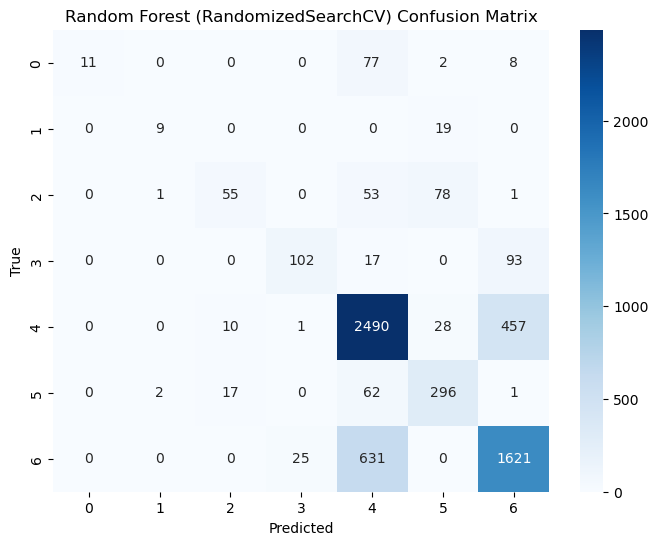

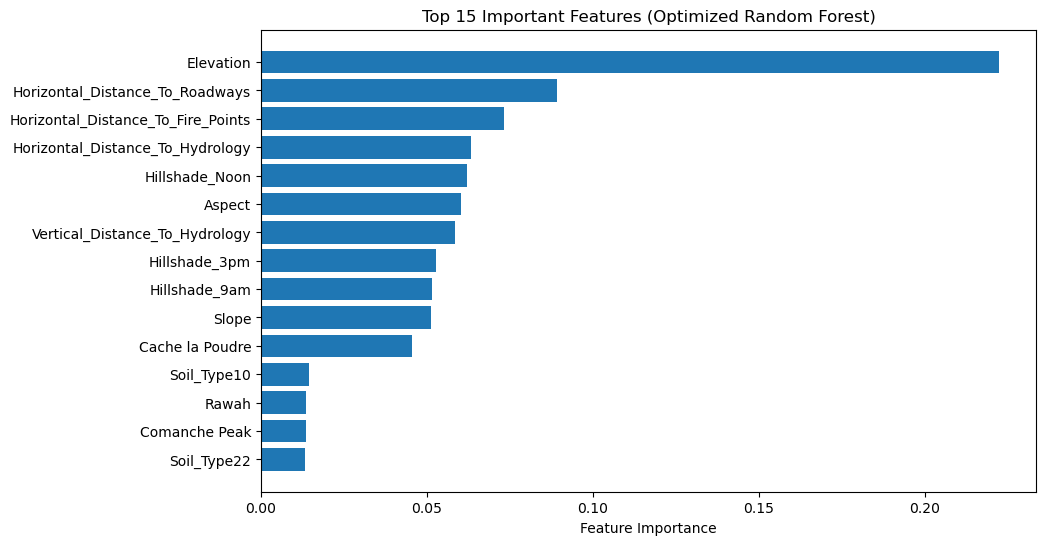

In [ ]:
# Read the dataset

df = pd.read_csv("forest_cover_clean.csv")

# Features and Target Variables
X = df.drop(columns=["Forest_Cover"])
y = df["Forest_Cover"]

# Partitioning the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define Parameter Distribution
param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": [10, 20, 30, None],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"]
}

# Random Forest and Random Search
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,              # To accelerate processing speed, 30 sets of parameters were randomly sampled
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    scoring="accuracy"
)

random_search.fit(X_train, y_train)

# Output optimal parameters and scores
print("Optimal parameter combination:", random_search.best_params_)
print(f"Cross-validation optimal accuracy: {random_search.best_score_:.4f}")

# Using the optimal model for prediction
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Model Evaluation
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of Random Forest on the Test Set: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest (RandomizedSearchCV) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature Importance Plot
importances = best_rf.feature_importances_
indices = importances.argsort()[-15:][::-1]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices][::-1], align='center')
plt.yticks(range(len(indices)), X.columns[indices][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features (Optimized Random Forest)")
plt.show()